# Detector de Autenticidad de Billetes IR

Pipeline híbrido sin deep learning para Raspberry Pi Zero 2W:

**Ensemble A + D:**
- **A: LBP + SVM** → captura micro-textura (patrones de impresión IR)
- **D: DCT + RandomForest** → captura espectro de frecuencia (tintas reactivas)
- **Score = 0.6 × LBP_SVM + 0.4 × DCT_RF**

---
## Flujo
1. Cargar crops de `segmentos_ir_billetes/`
2. Extraer features LBP y DCT por cada grupo feature/denominación
3. Entrenar SVM (LBP) y RandomForest (DCT) con solo billetes reales
4. Generar anomalías sintéticas para validación
5. Calibrar umbrales
6. Exportar modelos para Raspberry Pi
---

In [13]:
# ============================================================
# 1. DEPENDENCIAS
# ============================================================
# !pip install scikit-learn scikit-image joblib tqdm matplotlib seaborn

In [24]:
from pathlib import Path
import numpy as np
import random
import joblib
import json
from collections import defaultdict
from tqdm.notebook import tqdm

from PIL import Image
from skimage.feature import local_binary_pattern
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold

import matplotlib.pyplot as plt
import seaborn as sns

print("OK")

OK


---
## 2. Configuración
---

In [25]:
# ============================================================
# 2. CONFIGURACION
# ============================================================

SEGMENTS_DIR = Path("../Data/raw/segmentos_ir_billetes")
MODELS_DIR = Path("../Models/autenticidad_ir")

MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Mapeo de lado esperado por tipo de feature
# serie_a y personaje siempre van en anverso, animal siempre en reverso
# valor y valor_ir aparecen en ambos lados pero los tratamos separados

print(f"Crops: {SEGMENTS_DIR}")
print(f"Modelos: {MODELS_DIR}")

Crops: ../Data/raw/segmentos_ir_billetes
Modelos: ../Models/autenticidad_ir


---
## 3. Cargar crops y organizar por grupo (feature + denominación)
---

In [16]:
# ============================================================
# 3. CARGAR CROPS
# ============================================================

def load_crops(segments_dir):
    """
    Retorna dict:
        grupos[(feature_label, denominacion, lado)] = [np.array, ...]
    """
    grupos = defaultdict(list)
    sizes = defaultdict(list)

    for denom_dir in sorted(segments_dir.iterdir()):
        if not denom_dir.is_dir():
            continue
        denom = denom_dir.name  # "100_Bs"
        for lado_dir in sorted(denom_dir.iterdir()):
            if not lado_dir.is_dir():
                continue
            lado = lado_dir.name  # "anverso" o "reverso"
            for label_dir in sorted(lado_dir.iterdir()):
                if not label_dir.is_dir():
                    continue
                label = label_dir.name  # "serie_a", "personaje_100bs", etc.
                for img_path in sorted(label_dir.glob("*.png")):
                    img = Image.open(img_path).convert("L")
                    arr = np.array(img, dtype=np.uint8)
                    key = (label, denom, lado)
                    grupos[key].append(arr)
                    sizes[key].append(arr.shape)

    return grupos, sizes


grupos, sizes = load_crops(SEGMENTS_DIR)

# Reporte
print(f"Grupos encontrados: {len(grupos)}")
for key in sorted(grupos.keys()):
    label, denom, lado = key
    crops = grupos[key]
    dims = sizes[key][0]
    print(f"  {label:25s} | {denom:8s} | {lado:8s} | {len(crops):4d} crops | {dims}")

Grupos encontrados: 30
  animal_100bs              | 100_Bs   | reverso  |   90 crops | (126, 71)
  animal_10bs               | 10_Bs    | reverso  |   90 crops | (102, 114)
  animal_200bs              | 200_Bs   | reverso  |   91 crops | (131, 52)
  animal_20bs               | 20_Bs    | reverso  |   90 crops | (133, 43)
  animal_50bs               | 50_Bs    | reverso  |   90 crops | (108, 113)
  personaje_100bs           | 100_Bs   | anverso  |   90 crops | (92, 103)
  personaje_10bs            | 10_Bs    | anverso  |   90 crops | (66, 78)
  personaje_200bs           | 200_Bs   | anverso  |   91 crops | (64, 84)
  personaje_20bs            | 20_Bs    | anverso  |   90 crops | (93, 110)
  personaje_50bs            | 50_Bs    | anverso  |   91 crops | (73, 101)
  serie_a                   | 100_Bs   | anverso  |  181 crops | (110, 26)
  serie_a                   | 10_Bs    | anverso  |  180 crops | (95, 21)
  serie_a                   | 200_Bs   | anverso  |  181 crops | (108, 26)
  s

---
## 4. Funciones de extracción de features

### LBP (Local Binary Patterns)
Captura micro-textura. Los billetes falsos en IR pierden detalles finos de impresión.

### DCT (Discrete Cosine Transform)
Captura espectro de frecuencias. Las tintas IR reactivas tienen patrones frecuenciales específicos.
---

In [17]:
# ============================================================
# 4. EXTRACTORES DE FEATURES
# ============================================================

def extract_lbp(image, P=8, R=1, n_bins=32):
    """
    Local Binary Patterns → histograma.
    P=8 puntos, R=1 radio → 256 patrones → histograma de n_bins bins.
    """
    lbp = local_binary_pattern(image, P, R, method="uniform")
    hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins))
    hist = hist.astype(np.float32)
    hist /= hist.sum() + 1e-10
    return hist


def extract_dct(image, n_coeffs=64):
    """
    DCT 2D → zigzag scan → top n_coeffs de baja/media frecuencia.
    Ignora DC (primer coeficiente = brillo global).
    """
    from scipy.fftpack import dct
    dct2d = dct(dct(image.astype(np.float32).T, norm="ortho").T, norm="ortho")
    # Zigzag scan simplificado: flatten y ordenar por magnitud de frecuencia
    h, w = dct2d.shape
    zigzag = []
    for s in range(1, min(h, w)):  # skip DC (s=0)
        for i in range(s + 1):
            j = s - i
            if i < h and j < w:
                zigzag.append(dct2d[i, j])
            if j != i and j < h and i < w:
                zigzag.append(dct2d[j, i])
        if len(zigzag) >= n_coeffs:
            break
    coeffs = np.array(zigzag[:n_coeffs], dtype=np.float32)
    # Normalizar (sin DC)
    std = coeffs.std() + 1e-10
    coeffs = (coeffs - coeffs.mean()) / std
    return coeffs


def extract_features(crops, feature_type="lbp"):
    """Extrae features de una lista de crops (np.arrays)"""
    X = []
    for crop in crops:
        if feature_type == "lbp":
            feat = extract_lbp(crop)
        else:  # dct
            feat = extract_dct(crop)
        X.append(feat)
    return np.array(X)


# Test rápido
test_crop = list(grupos.values())[0][0]
print(f"LBP shape: {extract_lbp(test_crop).shape}")
print(f"DCT shape: {extract_dct(test_crop).shape}")
print("Extractores OK")

LBP shape: (32,)
DCT shape: (64,)
Extractores OK


---
## 5. Entrenar un modelo por grupo (LBP+SVM + DCT+RF)
---

In [18]:
# ============================================================
# 5. ENTRENAR MODELOS POR GRUPO
# ============================================================

def train_group(crops_reales, group_name, modelos_dir):
    """
    Entrena LBP+SVM y DCT+RF para un grupo de crops reales.
    Retorna dict con modelos, scalers, y umbrales calibrados.
    """
    n = len(crops_reales)
    if n < 10:
        print(f"  {group_name}: MUY POCOS CROPS ({n}), saltando...")
        return None

    # --- LBP + SVM ---
    X_lbp = extract_features(crops_reales, "lbp")
    scaler_lbp = StandardScaler()
    X_lbp_scaled = scaler_lbp.fit_transform(X_lbp)

    # SVM: solo datos reales → OneClass SVM
    from sklearn.svm import OneClassSVM
    svm = OneClassSVM(kernel="rbf", nu=0.05, gamma="scale")
    svm.fit(X_lbp_scaled)

    # Scores de entrenamiento para calibrar umbral
    scores_lbp = svm.decision_function(X_lbp_scaled)
    umbral_lbp = np.percentile(scores_lbp, 1)  # 1% más bajo = anómalo

    # --- DCT + RandomForest ---
    X_dct = extract_features(crops_reales, "dct")
    scaler_dct = StandardScaler()
    X_dct_scaled = scaler_dct.fit_transform(X_dct)

    # RF: Isolation Forest para detección de anomalías
    from sklearn.ensemble import IsolationForest
    iso = IsolationForest(n_estimators=50, contamination=0.05, random_state=42)
    iso.fit(X_dct_scaled)

    scores_dct = iso.decision_function(X_dct_scaled)
    umbral_dct = np.percentile(scores_dct, 1)

    # --- ENSEMBLE ---
    scores_ens = 0.6 * scores_lbp + 0.4 * scores_dct
    umbral_ens = np.percentile(scores_ens, 1)

    model_data = {
        "group_name": group_name,
        "n_crops": n,
        "scaler_lbp": scaler_lbp,
        "model_lbp": svm,
        "umbral_lbp": float(umbral_lbp),
        "scaler_dct": scaler_dct,
        "model_dct": iso,
        "umbral_dct": float(umbral_dct),
        "umbral_ensemble": float(umbral_ens),
    }

    # Guardar
    safe_name = group_name.replace("/", "_")
    joblib.dump(model_data, str(modelos_dir / f"{safe_name}.joblib"))

    return model_data


# Entrenar todos los grupos
modelos = {}
for key, crops in tqdm(sorted(grupos.items()), desc="Entrenando grupos"):
    label, denom, lado = key
    group_name = f"{label}/{denom}/{lado}"
    model_data = train_group(crops, group_name, MODELS_DIR)
    if model_data:
        modelos[key] = model_data

print(f"\nModelos entrenados: {len(modelos)}")
for key, m in sorted(modelos.items()):
    print(f"  {key}: {m['n_crops']} crops, umb_ens={m['umbral_ensemble']:.4f}")

Entrenando grupos:   0%|          | 0/30 [00:00<?, ?it/s]


Modelos entrenados: 30
  ('animal_100bs', '100_Bs', 'reverso'): 90 crops, umb_ens=-0.0048
  ('animal_10bs', '10_Bs', 'reverso'): 90 crops, umb_ens=-0.0011
  ('animal_200bs', '200_Bs', 'reverso'): 91 crops, umb_ens=-0.0007
  ('animal_20bs', '20_Bs', 'reverso'): 90 crops, umb_ens=-0.0053
  ('animal_50bs', '50_Bs', 'reverso'): 90 crops, umb_ens=-0.0008
  ('personaje_100bs', '100_Bs', 'anverso'): 90 crops, umb_ens=-0.0087
  ('personaje_10bs', '10_Bs', 'anverso'): 90 crops, umb_ens=-0.0017
  ('personaje_200bs', '200_Bs', 'anverso'): 91 crops, umb_ens=-0.0021
  ('personaje_20bs', '20_Bs', 'anverso'): 90 crops, umb_ens=0.0014
  ('personaje_50bs', '50_Bs', 'anverso'): 91 crops, umb_ens=0.0050
  ('serie_a', '100_Bs', 'anverso'): 181 crops, umb_ens=-0.0127
  ('serie_a', '10_Bs', 'anverso'): 180 crops, umb_ens=-0.0085
  ('serie_a', '200_Bs', 'anverso'): 181 crops, umb_ens=-0.0156
  ('serie_a', '20_Bs', 'anverso'): 180 crops, umb_ens=0.0062
  ('serie_a', '50_Bs', 'anverso'): 184 crops, umb_ens=-0

---
## 6. Generar anomalías sintéticas para validación
---

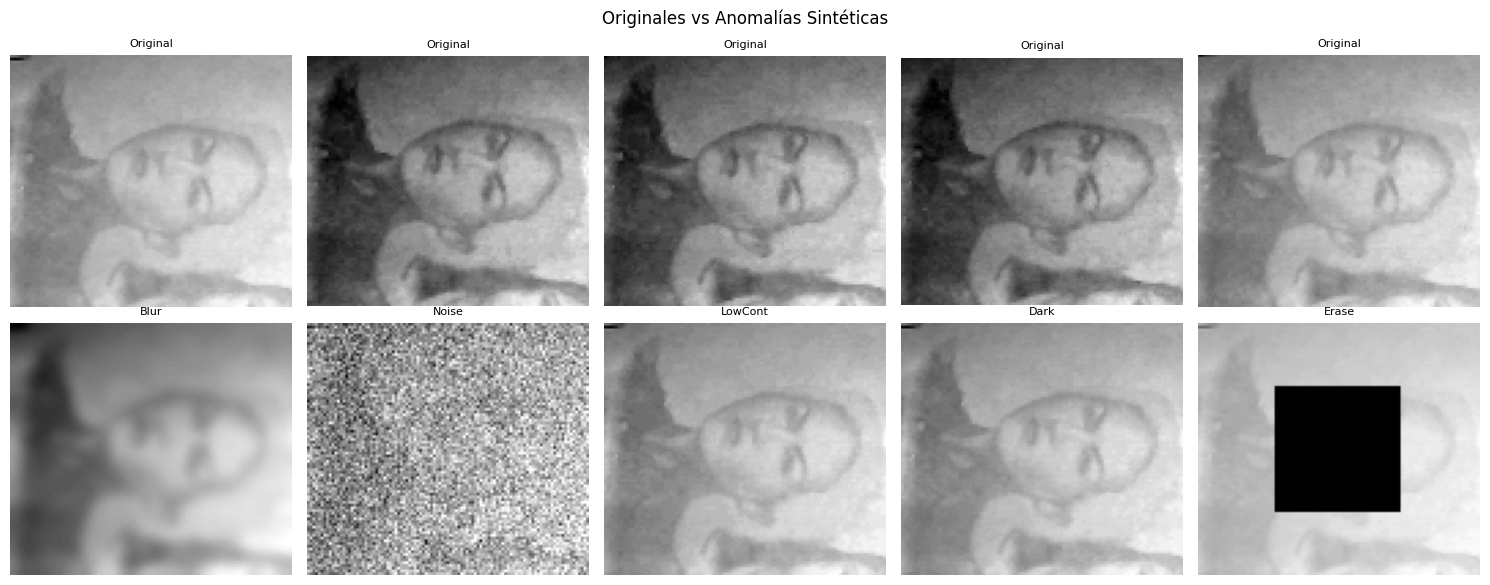

In [19]:
# ============================================================
# 6. ANOMALIAS SINTETICAS
# ============================================================

def generar_anomalias(crops_reales, n_per_type=5):
    """
    Genera versiones degradadas de crops reales:
    - blur: pérdida de detalles (simula falsos borrosos)
    - noise: ruido aleatorio (simula mala impresión)
    - low_contrast: bajo contraste (simula tinta no IR-reactiva)
    - dark: oscurecido (simula iluminación pobre)
    - erase: parche negro (simula falta de feature)
    """
    from scipy.ndimage import gaussian_filter

    anomalias = []
    np.random.seed(42)

    for crop in crops_reales[:min(len(crops_reales), n_per_type)]:
        h, w = crop.shape

        # Blur
        blurred = gaussian_filter(crop.astype(np.float32), sigma=2.0)
        anomalias.append(np.clip(blurred, 0, 255).astype(np.uint8))

        # Noise
        noise = crop.astype(np.float32) + np.random.randn(h, w) * 30
        anomalias.append(np.clip(noise, 0, 255).astype(np.uint8))

        # Bajo contraste
        low = crop.astype(np.float32) * 0.4 + 80
        anomalias.append(np.clip(low, 0, 255).astype(np.uint8))

        # Oscurecido
        dark = crop.astype(np.float32) * 0.5
        anomalias.append(np.clip(dark, 0, 255).astype(np.uint8))

        # Parche negro (simula feature faltante)
        erased = crop.copy()
        cx, cy = w // 2, h // 2
        r = min(w, h) // 4
        erased[cy-r:cy+r, cx-r:cx+r] = 0
        anomalias.append(erased)

    return anomalias


# Visualizar algunas
ejemplo_crops = list(grupos.values())[0][:5]
ejemplo_anomalias = generar_anomalias(ejemplo_crops, n_per_type=1)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
tipos = ["Original"] * 5 + ["Blur", "Noise", "LowCont", "Dark", "Erase"]
todas = ejemplo_crops[:5] + ejemplo_anomalias
for ax, img, tit in zip(axes.flat, todas, tipos):
    ax.imshow(img, cmap="gray")
    ax.set_title(tit, fontsize=8)
    ax.axis("off")
plt.suptitle("Originales vs Anomalías Sintéticas")
plt.tight_layout()
plt.show()

---
## 7. Validación: evaluar scores en originales vs sintéticos
---

In [20]:
# ============================================================
# 7. VALIDACION
# ============================================================

def score_crop(crop, model_data):
    """Calcula score ensemble para un crop"""
    # LBP
    feat_lbp = extract_lbp(crop).reshape(1, -1)
    feat_lbp_s = model_data["scaler_lbp"].transform(feat_lbp)
    score_lbp = model_data["model_lbp"].decision_function(feat_lbp_s)[0]

    # DCT
    feat_dct = extract_dct(crop).reshape(1, -1)
    feat_dct_s = model_data["scaler_dct"].transform(feat_dct)
    score_dct = model_data["model_dct"].decision_function(feat_dct_s)[0]

    # Ensemble
    score_ens = 0.6 * score_lbp + 0.4 * score_dct
    return score_ens, score_lbp, score_dct


# Evaluar
resultados = []
for key, model_data in tqdm(sorted(modelos.items()), desc="Validando"):
    crops_reales = grupos[key]
    anomalias = generar_anomalias(crops_reales, n_per_type=5)

    scores_real = []
    scores_fake = []

    # 80% de reales para test (no usados en train porque OCSVM/IsolationForest usan todos)
    np.random.seed(42)
    n_test = min(30, len(crops_reales))
    test_real = random.sample(crops_reales, n_test)

    for crop in test_real:
        s, _, _ = score_crop(crop, model_data)
        scores_real.append(s)

    for crop in anomalias:
        s, _, _ = score_crop(crop, model_data)
        scores_fake.append(s)

    umbral = model_data["umbral_ensemble"]
    tp = sum(1 for s in scores_real if s >= umbral)
    tn = sum(1 for s in scores_fake if s < umbral)

    acc = (tp + tn) / (len(scores_real) + len(scores_fake))
    resultados.append({
        "grupo": model_data["group_name"],
        "n_crops": model_data["n_crops"],
        "umbral": umbral,
        "real_medio": np.mean(scores_real),
        "fake_medio": np.mean(scores_fake),
        "tp": tp, "total_real": len(scores_real),
        "tn": tn, "total_fake": len(scores_fake),
        "acc": acc,
    })

# Reporte
print(f"\n{'Grupo':<40s} {'Crops':>6s} {'Umbral':>8s} {'Real':>8s} {'Fake':>8s} {'TP':>5s} {'TN':>5s} {'Acc':>6s}")
print("-" * 100)
accs = []
for r in sorted(resultados, key=lambda x: x["acc"], reverse=True):
    print(f"{r['grupo']:<40s} {r['n_crops']:>6d} {r['umbral']:>8.4f} "
          f"{r['real_medio']:>8.4f} {r['fake_medio']:>8.4f} "
          f"{r['tp']:>4d}/{r['total_real']:<3d} {r['tn']:>4d}/{r['total_fake']:<3d} "
          f"{r['acc']:>6.1%}")
    accs.append(r["acc"])

print(f"\nAccuracy promedio: {np.mean(accs):.1%}")
print(f"Accuracy minima: {np.min(accs):.1%}")

Validando:   0%|          | 0/30 [00:00<?, ?it/s]


Grupo                                     Crops   Umbral     Real     Fake    TP    TN    Acc
----------------------------------------------------------------------------------------------------
animal_10bs/10_Bs/reverso                    90  -0.0011   0.0731  -0.3217   30/30    25/25  100.0%
animal_200bs/200_Bs/reverso                  91  -0.0007   0.0798  -0.2649   30/30    25/25  100.0%
personaje_100bs/100_Bs/anverso               90  -0.0087   0.0850  -0.2985   30/30    25/25  100.0%
personaje_20bs/20_Bs/anverso                 90   0.0014   0.0626  -0.2611   30/30    25/25  100.0%
personaje_50bs/50_Bs/anverso                 91   0.0050   0.0744  -0.3184   30/30    25/25  100.0%
valor_50bs/50_Bs/anverso                     93  -0.0133   0.0757  -0.2683   30/30    25/25  100.0%
valor_ir_100bs/100_Bs/anverso                90  -0.0128   0.0733  -0.2866   30/30    25/25  100.0%
valor_ir_100bs/100_Bs/reverso                90  -0.0031   0.0769  -0.2444   30/30    25/25  100.0%
valo

---
## 8. Visualizar distribuciones de scores (real vs falso)
---

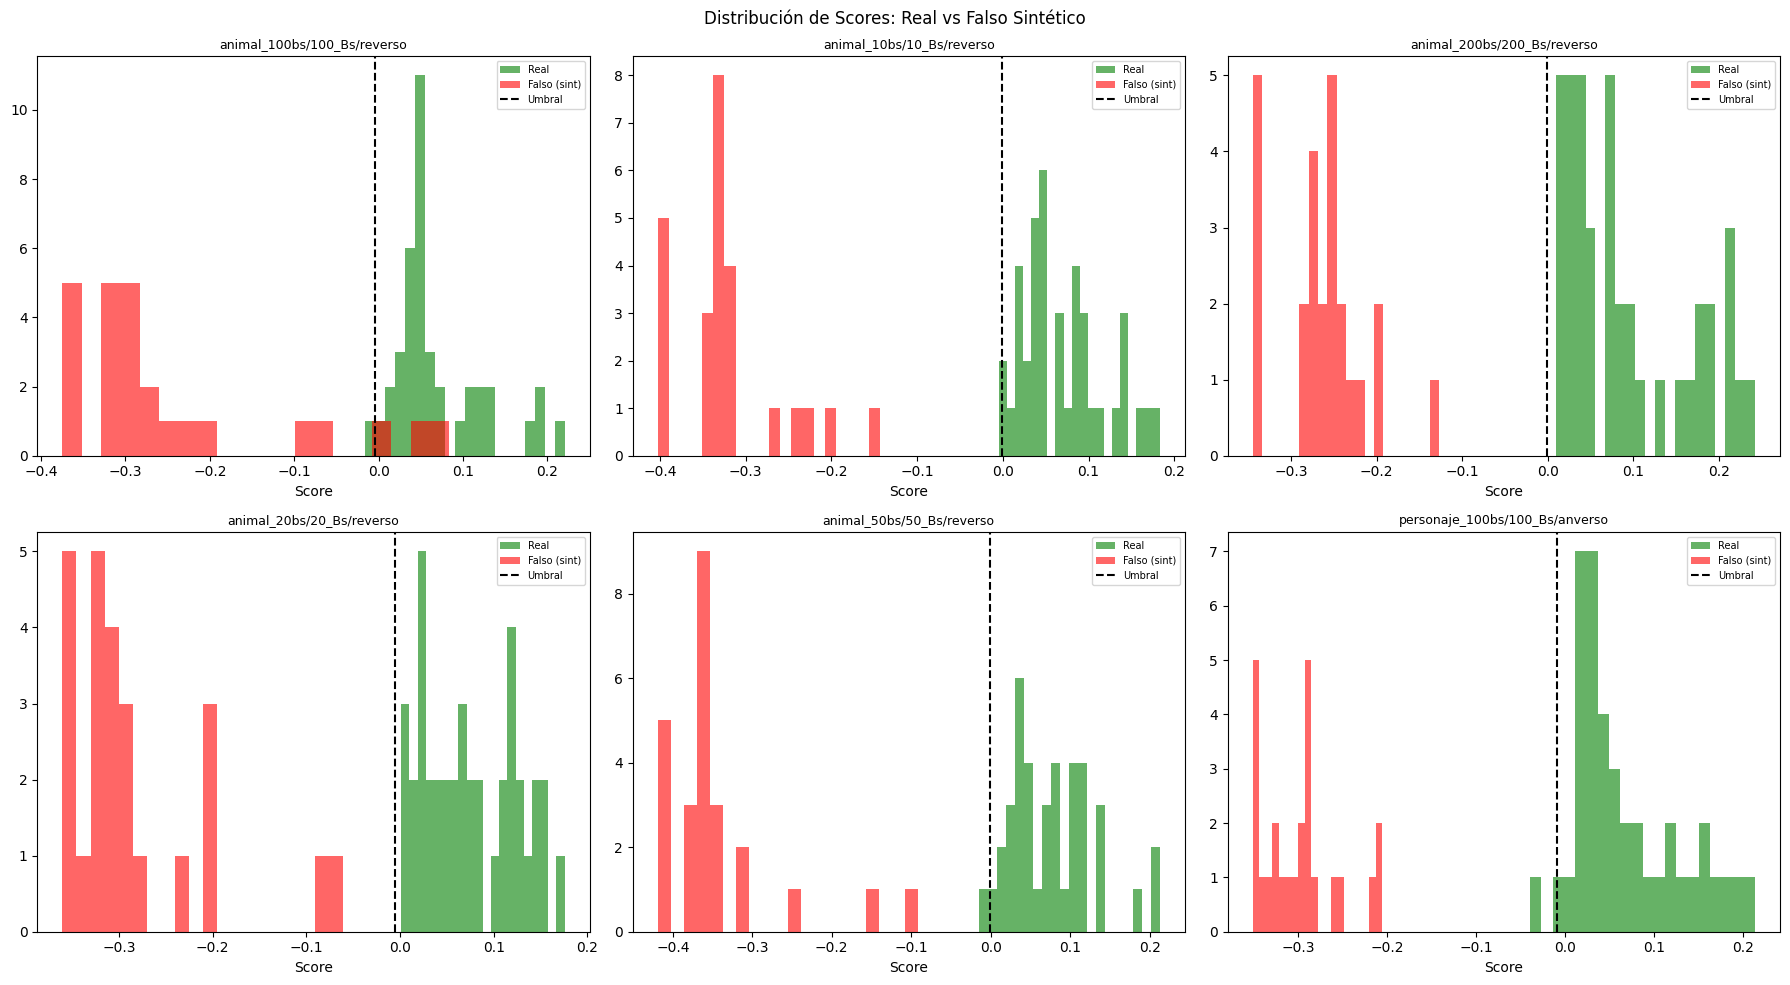

In [22]:
# ============================================================
# 8. VISUALIZACION
# ============================================================

# Elegir algunos grupos para visualizar
sample_keys = list(modelos.keys())[:6]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flat

for ax, key in zip(axes, sample_keys):
    crops_reales = grupos[key]
    anomalias = generar_anomalias(crops_reales, n_per_type=5)
    model_data = modelos[key]
    np.random.seed(42)
    idx = np.random.choice(len(crops_reales), size=min(40, len(crops_reales)), replace=False)
    test_real = [crops_reales[i] for i in idx]

    scores_r = [score_crop(c, model_data)[0] for c in test_real]
    scores_f = [score_crop(c, model_data)[0] for c in anomalias]

    ax.hist(scores_r, bins=20, alpha=0.6, label="Real", color="green")
    ax.hist(scores_f, bins=20, alpha=0.6, label="Falso (sint)", color="red")
    ax.axvline(model_data["umbral_ensemble"], color="black", linestyle="--", label="Umbral")
    ax.set_title(f"{key[0]}/{key[1]}/{key[2]}", fontsize=9)
    ax.legend(fontsize=7)
    ax.set_xlabel("Score")

plt.suptitle("Distribución de Scores: Real vs Falso Sintético")
plt.tight_layout()
plt.show()

---
## 9. Exportar para Raspberry Pi

Empaqueta todos los modelos en un solo archivo + metadata JSON.
---

In [23]:
# ============================================================
# 9. EXPORTAR
# ============================================================

def exportar_para_pi(modelos_dict, export_dir):
    """
    Crea un paquete listo para la Raspberry Pi:
    - modelos.joblib: todos los modelos comprimidos
    - metadata.json: umbrales, nombres de grupos, config
    - inferencia.py: script de ejemplo para la Pi
    """
    export_dir = Path(export_dir)
    export_dir.mkdir(parents=True, exist_ok=True)

    # Metadata
    metadata = {
        "version": "1.0",
        "feature_type": "LBP + DCT Ensemble",
        "score_formula": "0.6 * LBP_SVM + 0.4 * DCT_IsolationForest",
        "grupos": {}
    }

    for key, model_data in sorted(modelos_dict.items()):
        label, denom, lado = key
        group_name = f"{label}/{denom}/{lado}"
        metadata["grupos"][group_name] = {
            "label": label,
            "denominacion": denom,
            "lado": lado,
            "umbral_lbp": model_data["umbral_lbp"],
            "umbral_dct": model_data["umbral_dct"],
            "umbral_ensemble": model_data["umbral_ensemble"],
            "n_crops_entrenamiento": model_data["n_crops"],
        }

    with open(export_dir / "metadata.json", "w") as f:
        json.dump(metadata, f, indent=2, ensure_ascii=False)

    # Modelos comprimidos
    joblib.dump(dict(modelos_dict), str(export_dir / "modelos_autenticidad.joblib"),
                compress=3)

    # Script de inferencia
    infer_script = '''"""
Inferencia de autenticidad para Raspberry Pi Zero 2W.
Uso:
    from inferencia import AutenticidadDetector
    detector = AutenticidadDetector("modelos_autenticidad.joblib", "metadata.json")
    score = detector.evaluar(crop_imagen, label="serie_a", denominacion="100_Bs", lado="anverso")
    # score > 0 → probablemente real, score < 0 → probablemente falso
"""
import numpy as np
import joblib
import json
from pathlib import Path
from PIL import Image
from skimage.feature import local_binary_pattern
from scipy.fftpack import dct


class AutenticidadDetector:
    def __init__(self, modelos_path, metadata_path):
        self.modelos = joblib.load(modelos_path)
        with open(metadata_path) as f:
            self.metadata = json.load(f)

    def _extract_lbp(self, image, P=8, R=1, n_bins=32):
        lbp = local_binary_pattern(image, P, R, method="uniform")
        hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins))
        hist = hist.astype(np.float32)
        hist /= hist.sum() + 1e-10
        return hist

    def _extract_dct(self, image, n_coeffs=64):
        dct2d = dct(dct(image.astype(np.float32).T, norm="ortho").T, norm="ortho")
        h, w = dct2d.shape
        zigzag = []
        for s in range(1, min(h, w)):
            for i in range(s + 1):
                j = s - i
                if i < h and j < w:
                    zigzag.append(dct2d[i, j])
                if j != i and j < h and i < w:
                    zigzag.append(dct2d[j, i])
            if len(zigzag) >= n_coeffs:
                break
        coeffs = np.array(zigzag[:n_coeffs], dtype=np.float32)
        std = coeffs.std() + 1e-10
        coeffs = (coeffs - coeffs.mean()) / std
        return coeffs

    def evaluar(self, crop, label, denominacion, lado):
        """
        Evalúa un crop y retorna (score_ensemble, es_real, detalles).
        score > umbral → real, score < umbral → falso/anómalo.
        """
        if isinstance(crop, (str, Path)):
            crop = np.array(Image.open(crop).convert("L"), dtype=np.uint8)
        elif isinstance(crop, Image.Image):
            crop = np.array(crop.convert("L"), dtype=np.uint8)

        group_key = (label, denominacion, lado)
        if group_key not in self.modelos:
            raise ValueError(f"Grupo no encontrado: {group_key}")

        md = self.modelos[group_key]

        # LBP score
        feat_lbp = self._extract_lbp(crop).reshape(1, -1)
        feat_lbp_s = md["scaler_lbp"].transform(feat_lbp)
        score_lbp = md["model_lbp"].decision_function(feat_lbp_s)[0]

        # DCT score
        feat_dct = self._extract_dct(crop).reshape(1, -1)
        feat_dct_s = md["scaler_dct"].transform(feat_dct)
        score_dct = md["model_dct"].decision_function(feat_dct_s)[0]

        # Ensemble
        score_ens = 0.6 * score_lbp + 0.4 * score_dct
        es_real = score_ens >= md["umbral_ensemble"]

        detalles = {
            "score_lbp": float(score_lbp),
            "score_dct": float(score_dct),
            "score_ensemble": float(score_ens),
            "umbral": md["umbral_ensemble"],
            "es_real": bool(es_real),
        }

        return float(score_ens), bool(es_real), detalles


if __name__ == "__main__":
    import sys
    if len(sys.argv) < 5:
        print("Uso: python inferencia.py <crop.png> <label> <denominacion> <lado>")
        print("Ej: python inferencia.py crop.png serie_a 100_Bs anverso")
        sys.exit(1)
    detector = AutenticidadDetector("modelos_autenticidad.joblib", "metadata.json")
    score, es_real, detalles = detector.evaluar(sys.argv[1], sys.argv[2], sys.argv[3], sys.argv[4])
    print(f"Score: {score:.4f}")
    print(f"Es real: {es_real}")
    print(f"Detalles: {detalles}")
'''
    (export_dir / "inferencia.py").write_text(infer_script)

    size_mb = (export_dir / "modelos_autenticidad.joblib").stat().st_size / 1024 / 1024
    print(f"Exportado a: {export_dir}")
    print(f"  modelos_autenticidad.joblib: {size_mb:.1f} MB")
    print(f"  metadata.json")
    print(f"  inferencia.py")


EXPORT_DIR = MODELS_DIR / "raspberry_pi_package"
exportar_para_pi(modelos, EXPORT_DIR)

Exportado a: ../Models/autenticidad_ir/raspberry_pi_package
  modelos_autenticidad.joblib: 3.0 MB
  metadata.json
  inferencia.py


---
## 10. Resumen del pipeline para la Pi

```
K210 → Pi recibe:
  denominacion: "100_Bs"
  lado: "anverso"
  crops: [serie_a, serie_a, personaje_100bs, animal_100bs, valor_ir_100bs]

Pi:
  1. COUNT CHECK: ¿5 crops? Si no → penaliza
  2. Por cada crop:
     → detector.evaluar(crop, label, denom, lado)
     → score individual
  3. SCORE FINAL = min(scores)  (el más débil define)
  4. score > 0 → REAL
     score < 0 → FALSO (explicar cuál crop falló)
```

**Tiempo estimado en Pi Zero 2W:**
- LBP: <1ms
- SVM decision_function: <1ms
- DCT: ~2ms (scipy)
- RF decision_function: <1ms
- **Total por crop: ~5ms**
- **Total 5 crops: ~25ms**
---